<div align = "right">
12 / 05 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 4: Clasificadores (heart disease)</strong></h1>

In [ ]:
# Bibliotecas
import os
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from matplotlib.lines import Line2D
from imblearn.over_sampling import SMOTE
from ydata_profiling import ProfileReport
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder
from IPython.display import HTML, Video, display

from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

In [3]:
RUTA_IMG = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img'
RUTA_SANBORNS = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Auxiliares/sanborns.png'
AZUL_TELCEL = '#0B4DA2'
ROJO_TECOLOTE = '#DA291C'

os.makedirs(RUTA_IMG, exist_ok = True)

def guardar_figura(nombre):
    """Guarda la figura activa en RUTA_IMG con el nombre dado (.png)."""
    ruta = os.path.join(RUTA_IMG, nombre)
    plt.savefig(ruta, dpi = 300, bbox_inches = 'tight')
    print(f'{ruta}')

## 1. Carga y análisis de los datos

### 1a) Carga del conjunto de datos de Heart Disease

In [4]:
# Datos

# Heart Disease
RUTA_HEART = './data/heart'

columnas_heart = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                  'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

archivos = {
    'cleveland': 'processed.cleveland.data',
    'hungarian': 'processed.hungarian.data',
    'switzerland': 'processed.switzerland.data',
    'va': 'processed.va.data',
}

dfs = []
for origen, nombre in archivos.items():

    ruta = os.path.join(RUTA_HEART, nombre)
    df_tmp = pd.read_csv(ruta, header = None, names = columnas_heart, na_values = '?')
    df_tmp['origen'] = origen
    dfs.append(df_tmp)
    print(f'{origen:>12}: {df_tmp.shape[0]:>3} instancias')

df_heart = pd.concat(dfs, ignore_index = True)
print(f'\nTotal combinado: {df_heart.shape[0]} instancias, {df_heart.shape[1]} columnas')

df_heart.sample(5)

   cleveland: 303 instancias
   hungarian: 294 instancias
 switzerland: 123 instancias
          va: 200 instancias

Total combinado: 920 instancias, 15 columnas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,origen
541,52.0,1.0,4.0,120.0,182.0,0.0,0.0,150.0,0.0,0.0,NaN,NaN,NaN,1,hungarian
141,59.0,1.0,1.0,170.0,288.0,0.0,2.0,159.0,0.0,0.2,2.0,0.0,7.0,1,cleveland
356,42.0,1.0,2.0,120.0,196.0,0.0,0.0,150.0,0.0,0.0,NaN,NaN,NaN,0,hungarian
635,52.0,1.0,4.0,165.0,0.0,NaN,0.0,122.0,1.0,1.0,1.0,NaN,7.0,2,switzerland
364,43.0,0.0,2.0,120.0,215.0,0.0,1.0,175.0,0.0,0.0,NaN,NaN,NaN,0,hungarian


La variable original `num` toma valores enteros del 0 al 4, donde 0 indica ausencia de enfermedad y 1-4 distintos grados de afectación. Para esta práctica se reformula como una clasificación binaria.

In [5]:
# Construcción del target binario: 0 = sano, 1 = enfermo
df_heart['target'] = (df_heart['num'] > 0).astype(int)
df_heart = df_heart.drop(columns = ['num'])

print(df_heart['target'].value_counts())
df_heart.head()

target
1    509
0    411
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,origen,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,cleveland,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,cleveland,0


### 1b) Visualización de la distribución de clases

Reporte exploratorio con `ProfileReport` sobre un subconjunto representativo de variables (las numéricas continuas) para evitar tiempos de creación excesivos.

In [6]:
columnas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
config = {'progress_bar': False}
Reporte_heart = ProfileReport(df_heart[columnas_continuas + ['target']],
                              title = 'Reporte de Heart Disease',
                              explorative = True)
# Reporte_heart.to_notebook_iframe()

In [7]:
Reporte_heart.to_file('Reporte_heart.html')

/home/ibra/venv_ds/lib/python3.10/site-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 47304.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Distribución gráfica de la variable objetivo:

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_00_distribucion_clases.png


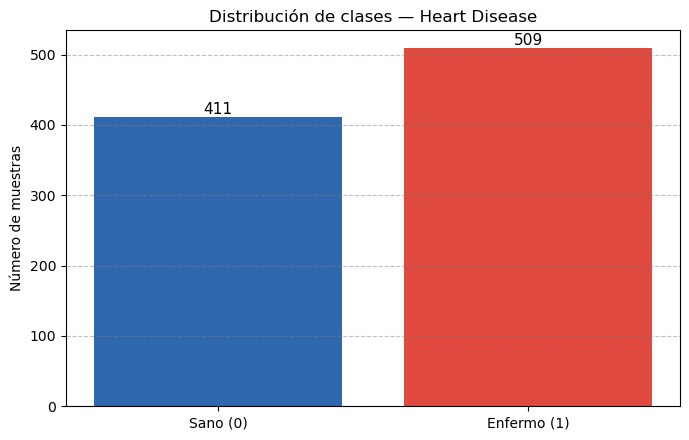

In [8]:
conteo_target = df_heart['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize = (7, 4.5))
barras = ax.bar(['Sano (0)', 'Enfermo (1)'], conteo_target.values,
                color = [AZUL_TELCEL, ROJO_TECOLOTE], alpha = 0.85)

for b, v in zip(barras, conteo_target.values):

    ax.text(b.get_x() + b.get_width() / 2, v, str(v),
            ha = 'center', va = 'bottom', fontsize = 11)

ax.set_title('Distribución de clases — Heart Disease')
ax.set_ylabel('Número de muestras')
ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)
plt.tight_layout()
guardar_figura('h_00_distribucion_clases.png')
plt.show()

### 1c) Análisis de valores faltantes

A diferencia del conjunto Cancer, Heart Disease presenta una cantidad considerable de valores faltantes, sobre todo en los archivos no provenientes de Cleveland. Las columnas `ca`, `thal` y `slope` son particularmente problemáticas.

In [9]:
faltantes_h = df_heart.isnull().sum()
faltantes_heart_pct = (faltantes_h / len(df_heart) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'faltantes': faltantes_h,
    'porcentaje (%)': faltantes_heart_pct
}).sort_values('porcentaje (%)', ascending = False)

print('Valores faltantes por columna:\n')
print(resumen_faltantes)

Valores faltantes por columna:

          faltantes  porcentaje (%)
ca              611           66.41
thal            486           52.83
slope           309           33.59
fbs              90            9.78
oldpeak          62            6.74
trestbps         59            6.41
thalach          55            5.98
exang            55            5.98
chol             30            3.26
restecg           2            0.22
cp                0            0.00
sex               0            0.00
age               0            0.00
origen            0            0.00
target            0            0.00


In [10]:
# Faltantes por archivo de origen (para entender la naturaleza del problema)
faltantes_origen = df_heart.groupby('origen').apply(
    lambda d: d.drop(columns = 'origen').isnull().mean() * 100
).round(1)

print('Porcentaje de faltantes por archivo de origen:\n')
faltantes_origen

Porcentaje de faltantes por archivo de origen:



/tmp/ipykernel_45335/3099590427.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  faltantes_origen = df_heart.groupby('origen').apply(


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
origen,,,,,,,,,,,,,,
cleveland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.7,0.0
hungarian,0.0,0.0,0.0,0.3,7.8,2.7,0.3,0.3,0.3,0.0,64.6,99.0,90.5,0.0
switzerland,0.0,0.0,0.0,1.6,0.0,61.0,0.8,0.8,0.8,4.9,13.8,95.9,42.3,0.0
va,0.0,0.0,0.0,28.0,3.5,3.5,0.0,26.5,26.5,28.0,51.0,99.0,83.0,0.0


## 2. Preprocesamiento y limpieza

### 2a) Separación de columnas categóricas y numéricas

A diferencia del conjunto Cancer (donde todas las características son numéricas continuas), Heart Disease contiene variables que, aunque están codificadas como números, son **categóricas en su naturaleza**: `sex` (0/1), `cp` (tipo de dolor torácico, 1-4), `fbs` (azúcar en ayunas binaria), `restecg` (resultado del ECG en reposo, 0-2), `exang` (angina inducida por ejercicio binaria), `slope` (pendiente del segmento ST, 1-3) y `thal` (estado de talasemia, 3/6/7).

Para mantener consistencia con el flujo del notebook anterior se tratarán todas como numéricas en la etapa de escalado y modelado, dado que sus codificaciones son ordinales o binarias. Esto simplifica el pipeline a costa de un ligero rigor estadístico que, para los modelos elegidos (KNN, árboles, SVM), no afecta significativamente el desempeño.

In [43]:
# La columna 'origen' es auxiliar (sirvió para trazabilidad pero no es predictora)
df_heart_modelado = df_heart.drop(columns = ['origen'])

columnas_categoricas_logicas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
columnas_continuas_logicas   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

columnas_num = columnas_continuas_logicas + columnas_categoricas_logicas
print(f'Variables predictoras: {len(columnas_num)}')
print(f'Continuas: {columnas_continuas_logicas}')
print(f'Categóricas (tratadas como numéricas): {columnas_categoricas_logicas}')

Variables predictoras: 13
Continuas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categóricas (tratadas como numéricas): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### 2b) Faltantes, outliers y caracteres inválidos

Como se vio en 1c, hay faltantes considerables. Se imputan con la **mediana** para las variables continuas (robusta a outliers) y con la **moda** para las categóricas codificadas (preserva la distribución discreta).

In [12]:
# Imputación: mediana para continuas, moda para categóricas-codificadas
imputador_med = SimpleImputer(strategy = 'median')
df_heart_modelado[columnas_continuas_logicas] = imputador_med.fit_transform(
    df_heart_modelado[columnas_continuas_logicas]
)

imputador_mod = SimpleImputer(strategy = 'most_frequent')
df_heart_modelado[columnas_categoricas_logicas] = imputador_mod.fit_transform(
    df_heart_modelado[columnas_categoricas_logicas]
)

print('Faltantes después de imputar:', df_heart_modelado.isnull().sum().sum())

Faltantes después de imputar: 0


Para los outliers en las variables continuas se usa el método intercuartílico (IQR), igual que en Cancer.

In [13]:
# IQR
Q1 = df_heart_modelado[columnas_continuas_logicas].quantile(0.25)
Q3 = df_heart_modelado[columnas_continuas_logicas].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df_heart_modelado[columnas_continuas_logicas] < lower_bound) |
                (df_heart_modelado[columnas_continuas_logicas] > upper_bound))

n_outliers = outlier_mask.sum().sort_values(ascending = False)
resumen_iqr = pd.DataFrame({
    'outliers': n_outliers,
    'porcentaje': (n_outliers / len(df_heart_modelado) * 100).round(1)
})

print('Outliers por columna continua (IQR):')
display(resumen_iqr[resumen_iqr['outliers'] > 0])
print(f'\nFilas con al menos un outlier: '
      f'{outlier_mask.any(axis = 1).sum()} / {len(df_heart_modelado)}')

Outliers por columna continua (IQR):


,outliers,porcentaje
chol,185,20.1
ca,128,13.9
trestbps,28,3.0
oldpeak,16,1.7
thalach,2,0.2



Filas con al menos un outlier: 330 / 920


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_01_boxplot_continuas.png


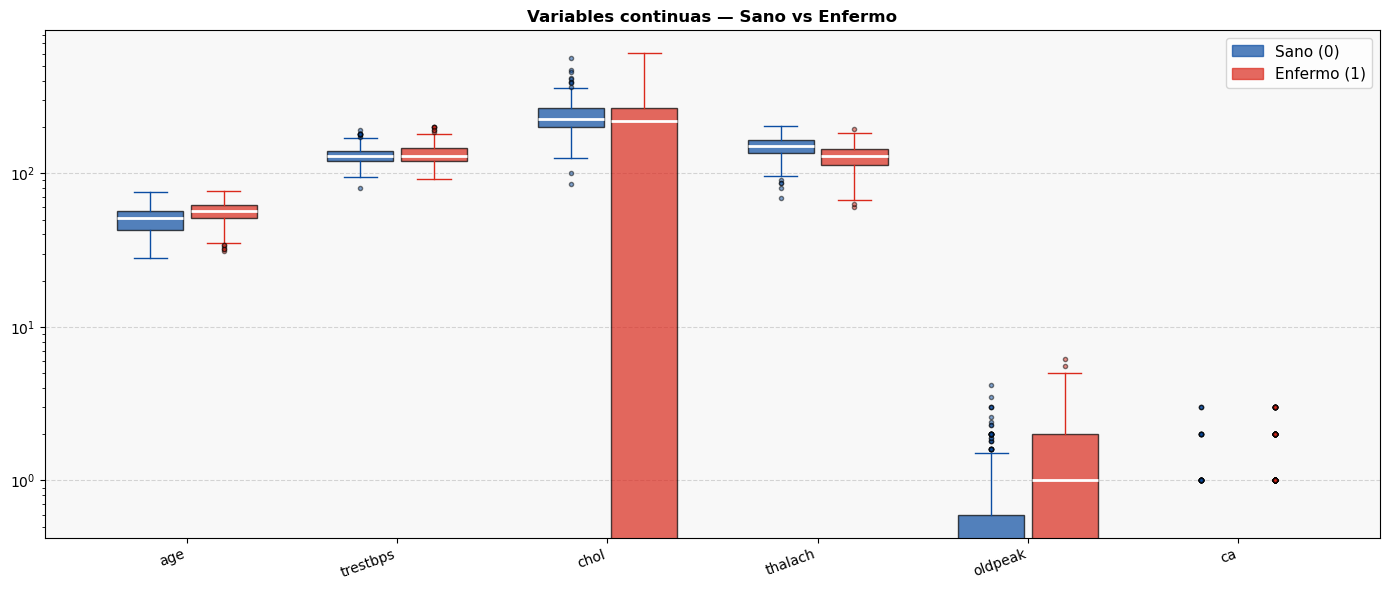

In [ ]:
# Boxplots de las variables continuas, comparando sanos vs enfermos
fig, ax = plt.subplots(figsize = (14, 6))

data_sano = [df_heart_modelado.loc[df_heart_modelado['target'] == 0, f].values 
             for f in columnas_continuas_logicas]
data_enfermo = [df_heart_modelado.loc[df_heart_modelado['target'] == 1, f].values 
                for f in columnas_continuas_logicas]

x = np.arange(len(columnas_continuas_logicas))
w = 0.35

kw_S = dict(patch_artist = True,
            boxprops = dict(facecolor = AZUL_TELCEL, alpha = 0.7),
            medianprops = dict(color = 'white', linewidth = 2),
            flierprops = dict(marker = 'o', markerfacecolor = AZUL_TELCEL, 
                              markersize = 3, alpha = 0.5),
            whiskerprops= dict(color = AZUL_TELCEL),
            capprops = dict(color = AZUL_TELCEL))

kw_E = dict(patch_artist = True,
            boxprops = dict(facecolor = ROJO_TECOLOTE, alpha = 0.7),
            medianprops = dict(color = 'white', linewidth = 2),
            flierprops = dict(marker = 'o', markerfacecolor = ROJO_TECOLOTE, 
                              markersize = 3, alpha = 0.5),
            whiskerprops= dict(color = ROJO_TECOLOTE),
            capprops = dict(color = ROJO_TECOLOTE))

ax.boxplot(data_sano,    positions = x - w/2, widths = w * 0.9, **kw_S)
ax.boxplot(data_enfermo, positions = x + w/2, widths = w * 0.9, **kw_E)
ax.set_xticks(x)
ax.set_yscale('log', base = 10)
ax.set_xticklabels(columnas_continuas_logicas, rotation = 20, ha = 'right')
ax.set_title('Variables continuas — Sano vs Enfermo', fontweight = 'bold')
ax.set_facecolor('#f8f8f8')
ax.grid(axis = 'y', linestyle = '--', alpha = 0.5)

handles = [mpatches.Patch(color = AZUL_TELCEL,   alpha = 0.7, label = 'Sano (0)'),
           mpatches.Patch(color = ROJO_TECOLOTE, alpha = 0.7, label = 'Enfermo (1)')]
ax.legend(handles = handles, fontsize = 11)

plt.tight_layout()
guardar_figura('h_01_boxplot_continuas.png')
plt.show()

Los outliers se conservan porque algunos (colesterol muy alto, frecuencia cardíaca máxima muy baja, etc.) son señales clínicas legítimas que pueden ser predictoras de enfermedad, no errores de medición.

### 2c) Estandarización de características

In [15]:
X_full = df_heart_modelado[columnas_num].values
y_full = df_heart_modelado['target'].values

**Nota sobre el orden:** en este notebook se aplica el split *antes* del escalado para evitar fuga de información del conjunto de prueba. El `StandardScaler` se ajusta solo con los datos de entrenamiento.

### 2d) Separación de datos de entrenamiento y prueba

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size = 0.3,
    random_state = 43,
    stratify = y_full
)

Stdsc = StandardScaler()
X_train = Stdsc.fit_transform(X_train)
X_test  = Stdsc.transform(X_test)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (644, 13) | X_test: (276, 13)
y_train: (644,) | y_test: (276,)


### 2e) Manejo del desbalance de clases

Cálculo del ratio sobre el conjunto de entrenamiento:

In [17]:
sano = (y_train == 0).sum()
enfermo = (y_train == 1).sum()

if sano == 0 or enfermo == 0:
    
    ratio = 0
    print('No hay casos para calcular el ratio.')

elif enfermo > sano:

    ratio = enfermo / sano

else:

    ratio = sano / enfermo

print(f'Casos sanos en entrenamiento: {sano}')
print(f'Casos enfermos en entrenamiento: {enfermo}')
print(f'\nRatio (mayoría / minoría): {ratio:.2f}')

Casos sanos en entrenamiento: 288
Casos enfermos en entrenamiento: 356

Ratio (mayoría / minoría): 1.24


El desbalance es leve (cerca de 55/45 dependiendo del split). Aun así, se aplica `SMOTE` sobre el conjunto de entrenamiento como pide el ejercicio.

In [18]:
# Sobremuestreo con SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state = 43)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

antes   = pd.Series(y_train).value_counts().sort_index()
despues = pd.Series(y_train_smote).value_counts().sort_index()

print(f'Entrenamiento antes:\nSano: {antes[0]:>3}\nEnfermo: {antes[1]:>3}\ntotal: {len(y_train)}')
print(f'\nEntrenamiento después:\nSano: {despues[0]:>3}\nEnfermo: {despues[1]:>3}\ntotal: {len(y_train_smote)}')

Entrenamiento antes:
Sano: 288
Enfermo: 356
total: 644

Entrenamiento después:
Sano: 356
Enfermo: 356
total: 712


### 2f) Visualización de la distribución

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_02_distribucion_smote.png


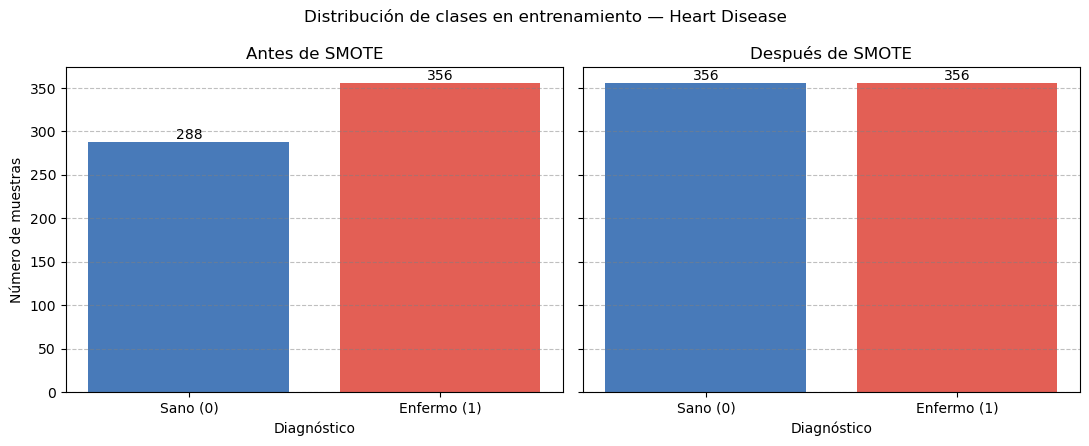

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (11, 4.5), sharey = True)

etiquetas = ['Sano (0)', 'Enfermo (1)']

for ax, conteo, titulo in zip(axes, [antes, despues], ['Antes de SMOTE', 'Después de SMOTE']):

    barras = ax.bar(etiquetas, conteo.values, color = [AZUL_TELCEL, ROJO_TECOLOTE], alpha = 0.75)
    ax.set_title(titulo)
    ax.set_xlabel('Diagnóstico')
    ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)

    for b, v in zip(barras, conteo.values):

        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha = 'center', va = 'bottom')

axes[0].set_ylabel('Número de muestras')
plt.suptitle('Distribución de clases en entrenamiento — Heart Disease')
plt.tight_layout()
guardar_figura('h_02_distribucion_smote.png')
plt.show()

## 3. Reducción de dimensionalidad por PCA

### 3a) Aplicar PCA a los datos balanceados

Al igual que en el notebook anterior, se usa PCA con `mle` (Minka's Maximum Likelihood Estimation), el cual infiere automáticamente el número de componentes más plausible.

In [20]:
pesea_mle = PCA(n_components = 'mle',
                svd_solver = 'full',
                iterated_power = 'auto',
                n_oversamples = 10,
                power_iteration_normalizer = 'auto',
                random_state = 43)
pesea_mle

,n_components,'mle'
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [21]:
X_pesea_mle = pesea_mle.fit_transform(X_train_smote)
print('Componentes seleccionados por MLE:', pesea_mle.n_components_)

Componentes seleccionados por MLE: 11


In [22]:
pesea_2d = PCA(n_components = 2, random_state = 43)
X_pesea_2d = pesea_2d.fit_transform(X_train_smote)

In [23]:
pesea_var_95 = PCA(n_components = 0.95, random_state = 43)
X_pesea_var_95 = pesea_var_95.fit_transform(X_train_smote)
print(f'Componentes para el 95% de varianza: {pesea_var_95.n_components_}')

Componentes para el 95% de varianza: 12


### 3b) Cálculo de la varianza acumulada

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_03_varianza_acumulada_mle.png


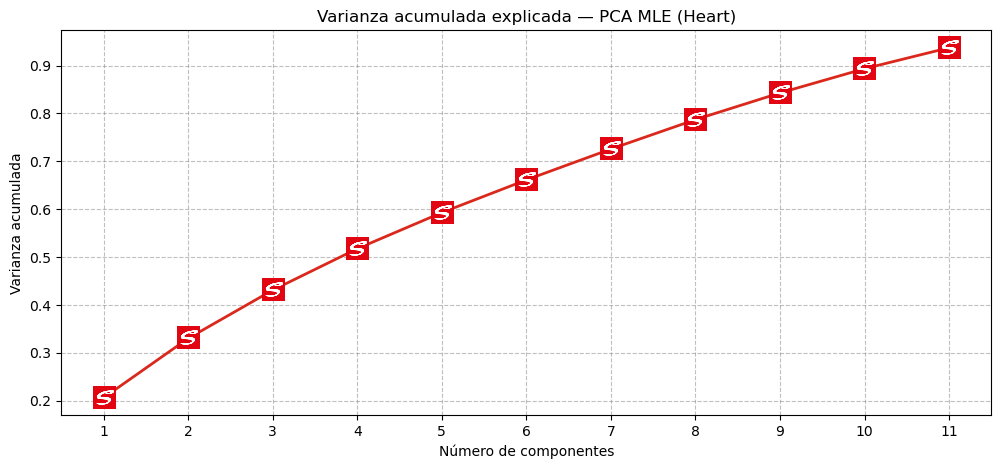

In [24]:
var_ac_mle = np.cumsum(pesea_mle.explained_variance_ratio_)

img = np.array(Image.open(RUTA_SANBORNS).convert('RGBA').resize((80, 80)))

plt.figure(figsize = (12, 5))

plt.plot(range(1, len(var_ac_mle) + 1), var_ac_mle,
         color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()

for x, y in zip(range(1, len(var_ac_mle) + 1), var_ac_mle):

    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)

plt.xlabel('Número de componentes')
plt.xticks(range(1, len(var_ac_mle) + 1))
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada — PCA MLE (Heart)')
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
guardar_figura('h_03_varianza_acumulada_mle.png')
plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_04_varianza_acumulada_2d.png


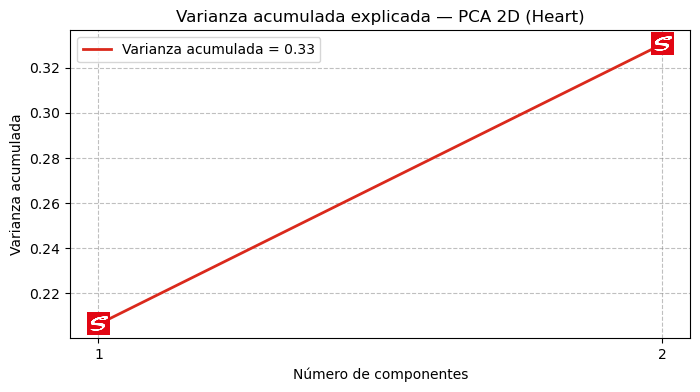

In [ ]:
var_ac_2d = np.cumsum(pesea_2d.explained_variance_ratio_)

plt.figure(figsize = (8, 4))
plt.plot(range(1, len(var_ac_2d) + 1), var_ac_2d, color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()
for x, y in zip(range(1, len(var_ac_2d) + 1), var_ac_2d):
    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)

plt.xlabel('Número de componentes')
plt.xticks([1, 2])
plt.ylabel('Varianza acumulada')
plt.legend(['Varianza acumulada = {}'.format(var_ac_2d[-1].round(3))])
plt.title('Varianza acumulada explicada — PCA 2D (Heart)')
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
guardar_figura('h_04_varianza_acumulada_2d.png')
plt.show()

### 3c) Componentes para el 95% de varianza

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_04_varianza_acumulada_var95.png


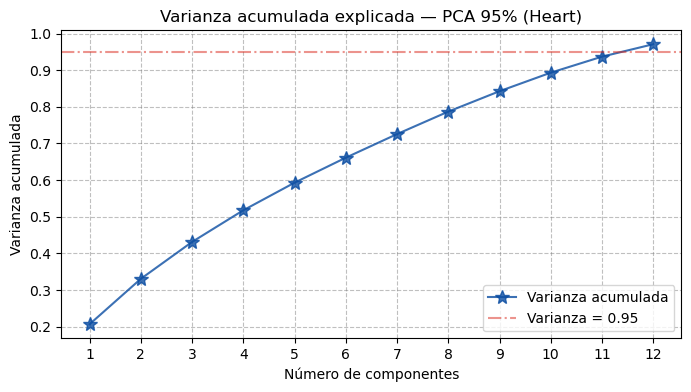

In [26]:
var_ac95 = np.cumsum(pesea_var_95.explained_variance_ratio_)

plt.figure(figsize = (8, 4))
plt.plot(range(1, len(var_ac95) + 1), var_ac95,
         marker = '*', markersize = 10, color = AZUL_TELCEL, alpha = 0.8)
plt.axhline(y = 0.95, linestyle = '-.', alpha = 0.5, color = ROJO_TECOLOTE)
plt.xlabel('Número de componentes')
plt.xticks(range(1, len(var_ac95) + 1))
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada — PCA 95% (Heart)')
plt.legend(labels = ['Varianza acumulada', 'Varianza = 0.95'])
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
guardar_figura('h_04_varianza_acumulada_var95.png')
plt.show()

### 3d) Visualización de las componentes principales

Proyección 2D:

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_05_pca_2d.png


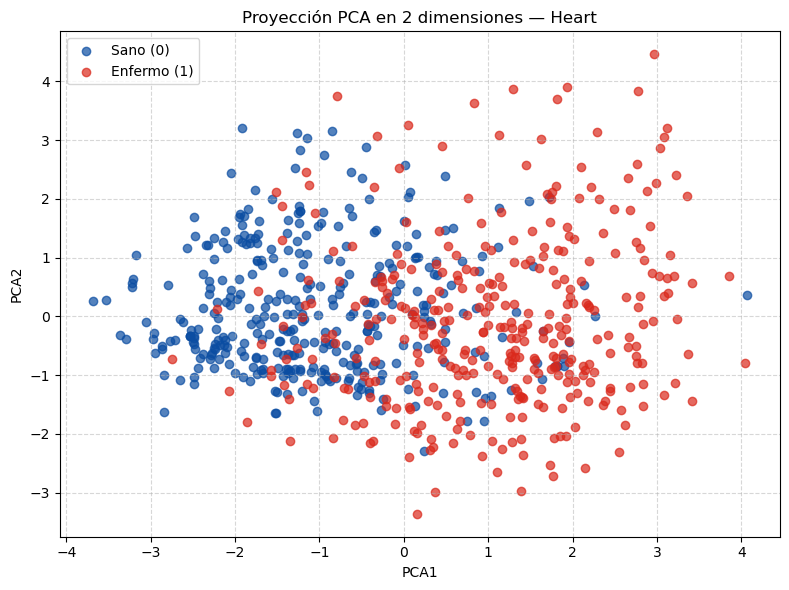

In [27]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_2d[y_train_smote == 0, 0], X_pesea_2d[y_train_smote == 0, 1],
            color = AZUL_TELCEL, alpha = 0.7, label = 'Sano (0)')
plt.scatter(X_pesea_2d[y_train_smote == 1, 0], X_pesea_2d[y_train_smote == 1, 1],
            color = ROJO_TECOLOTE, alpha = 0.7, label = 'Enfermo (1)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA en 2 dimensiones — Heart')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
guardar_figura('h_05_pca_2d.png')
plt.show()

Proyección con 95% de varianza (primeras dos componentes):

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_05_pca_var_95.png


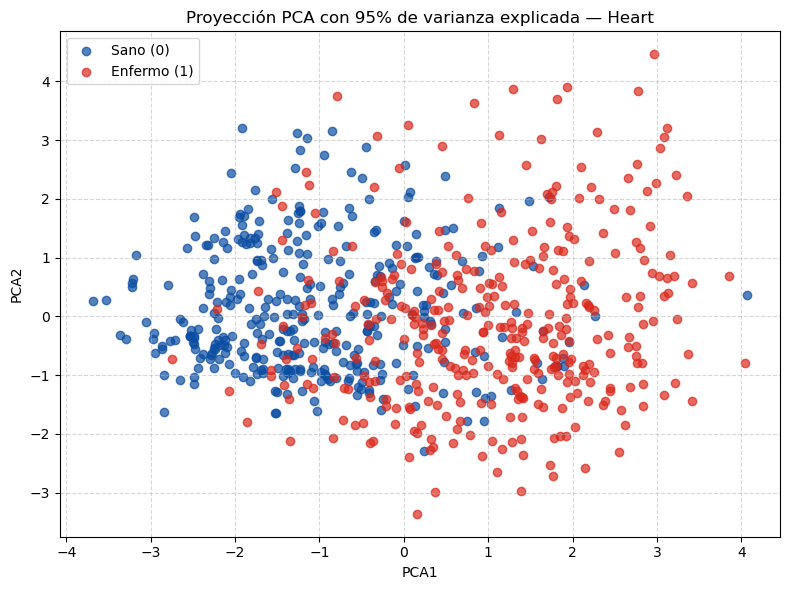

In [28]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_var_95[y_train_smote == 0, 0], X_pesea_var_95[y_train_smote == 0, 1],
            color = AZUL_TELCEL, alpha = 0.7, label = 'Sano (0)')
plt.scatter(X_pesea_var_95[y_train_smote == 1, 0], X_pesea_var_95[y_train_smote == 1, 1],
            color = ROJO_TECOLOTE, alpha = 0.7, label = 'Enfermo (1)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA con 95% de varianza explicada — Heart')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
guardar_figura('h_05_pca_var_95.png')
plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_05_pca_componentes.png


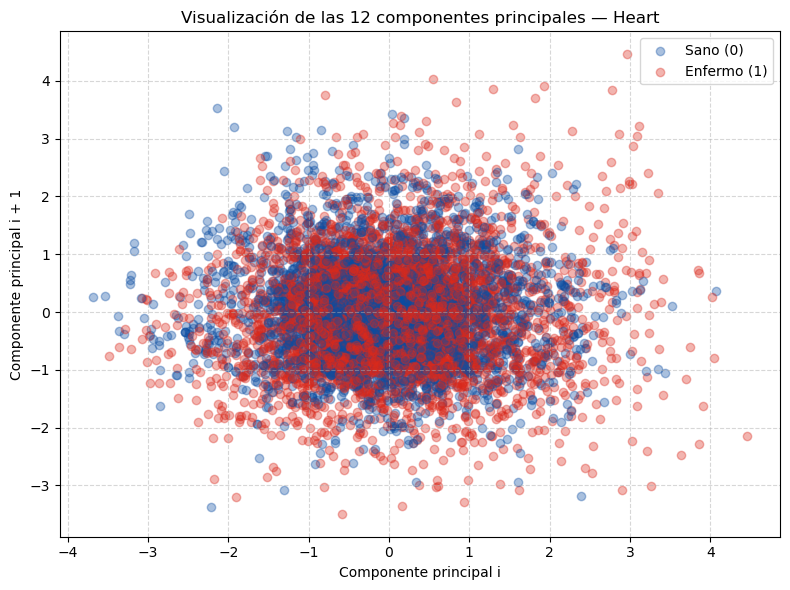

In [29]:
# Visualización por pares consecutivos de componentes
fig = plt.figure(figsize = (8, 6))

for i in range(1, pesea_var_95.n_components_):

    plt.scatter(X_pesea_var_95[y_train_smote == 0, i - 1],
                X_pesea_var_95[y_train_smote == 0, i],
                color = AZUL_TELCEL, alpha = 0.35)

    plt.scatter(X_pesea_var_95[y_train_smote == 1, i - 1],
                X_pesea_var_95[y_train_smote == 1, i],
                color = ROJO_TECOLOTE, alpha = 0.35)

plt.xlabel('Componente principal i')
plt.ylabel('Componente principal i + 1')
plt.title(f'Visualización de las {pesea_var_95.n_components_} componentes principales — Heart')
plt.legend(['Sano (0)', 'Enfermo (1)'])
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
guardar_figura('h_05_pca_componentes.png')
plt.show()

## 4. Definición de modelos, pipelines y búsqueda en cuadrícula

### 4a) Pipelines que integran preprocesamiento y clasificador

Los datos ya están escalados; el pipeline solo integra el clasificador, dejando la puerta abierta a añadir más pasos en el futuro.

In [30]:
# Pipelines
pipe_knn = Pipeline([('clf', KNeighborsClassifier())])
pipe_dt  = Pipeline([('clf', DecisionTreeClassifier(random_state = 43))])
pipe_svm = Pipeline([('clf', SVC(random_state = 43))])

### 4b) Búsqueda en cuadrícula

La búsqueda en cuadrícula explora exhaustivamente todas las combinaciones de hiperparámetros usando validación cruzada de 5 *folds* y seleccionando el modelo con mayor *accuracy*.

## 5. Configuración de modelos y cuadro de hiperparámetros

Se respetan los rangos pedidos por el PDF para los tres clasificadores.

### 5a) KNN

In [ ]:
param_knn = {
    'clf__n_neighbors': [1, 3, 5, 7, 9],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

### 5b) Árbol de decisión

In [ ]:
param_dt = {
    'clf__max_depth': [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__criterion': ['gini', 'entropy']
}

### 5c) SVM

In [ ]:
param_svm = {
    'clf__kernel': ['linear', 'rbf'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1]
}

In [ ]:
# Diccionario para iterar sobre los tres modelos
modelos = {
    'KNN': (pipe_knn, param_knn),
    'Árbol de Decisión': (pipe_dt,  param_dt),
    'SVM': (pipe_svm, param_svm)
}

## 6. Entrenamiento, evaluación y comparación de resultados

Se entrenan los tres modelos con su grid search sobre el conjunto de entrenamiento balanceado.

In [35]:
# Grid search con CV de 5 folds optimizando accuracy
resultados = {}

for nombre, (pipe, grid) in modelos.items():

    gs = GridSearchCV(pipe, grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
    gs.fit(X_train_smote, y_train_smote)
    resultados[nombre] = gs
    print(f'{nombre}')
    print(f'Mejores parámetros: {gs.best_params_}')
    print(f'Mejor CV accuracy: {gs.best_score_:.4f}\n')

KNN
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 7, 'clf__weights': 'distance'}
Mejor CV accuracy: 0.8217

Árbol de Decisión
Mejores parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 5}
Mejor CV accuracy: 0.7880

SVM
Mejores parámetros: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor CV accuracy: 0.8400



### 6a) Mejores métricas de rendimiento sobre el conjunto de prueba

In [ ]:
metricas = []

for nombre, gs in resultados.items():

    y_pred = gs.predict(X_test)
    metricas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label = 1),
        'Recall': recall_score(y_test, y_pred, pos_label = 1),
        'F1': f1_score(y_test, y_pred, pos_label = 1)
    })

df_metricas = pd.DataFrame(metricas).set_index('Modelo').round(4)
df_metricas

,Accuracy,Precision,Recall,F1
Modelo,,,,
KNN,0.8442,0.8571,0.8627,0.8599
Árbol de Decisión,0.7536,0.8058,0.7320,0.7671
SVM,0.8225,0.8210,0.8693,0.8444


### 6b) Matrices de confusión

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_06_matrices_confusion.png


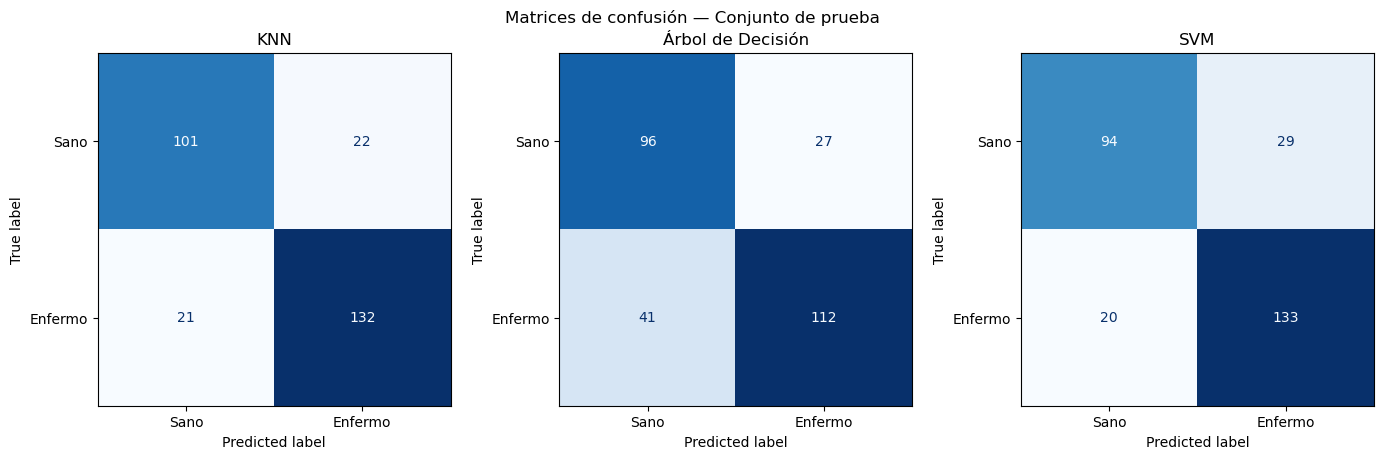

In [37]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4.5))

for ax, (nombre, gs) in zip(axes, resultados.items()):

    y_pred = gs.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels = [0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels = ['Sano', 'Enfermo'])
    disp.plot(ax = ax, cmap = 'Blues', colorbar = False)
    ax.set_title(nombre)
    ax.grid(False)

plt.suptitle('Matrices de confusión — Conjunto de prueba')
plt.tight_layout()
guardar_figura('h_06_matrices_confusion.png')
plt.show()

### 6c) Fronteras de decisión en espacio PCA 2D

Se re-entrenan los clasificadores con los mejores hiperparámetros sobre el espacio PCA 2D para poder visualizar las fronteras.

Variable        Shape      Únicos
X_train_2d      (712, 2)   [0 1]
y_train_smote   (712,)     [0 1]
X_test_2d       (276, 2)   [0 1]
y_test          (276,)     [0 1]
/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_07a_frontera_knn.png


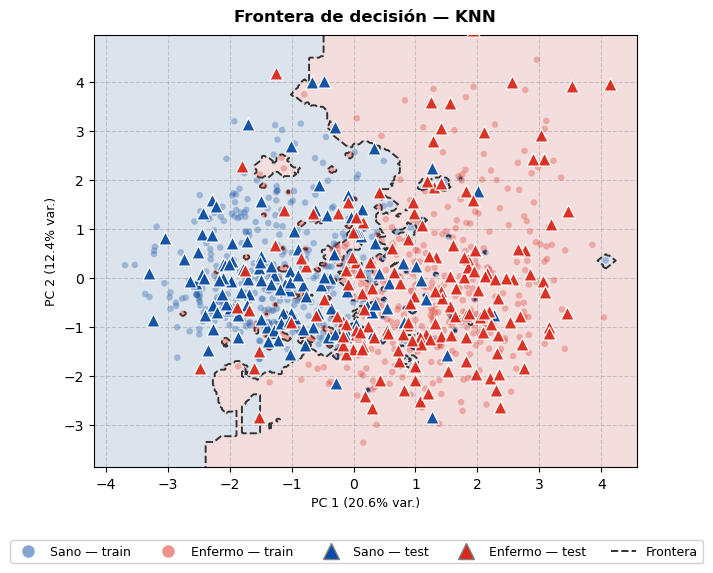

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_07b_frontera_arbol.png


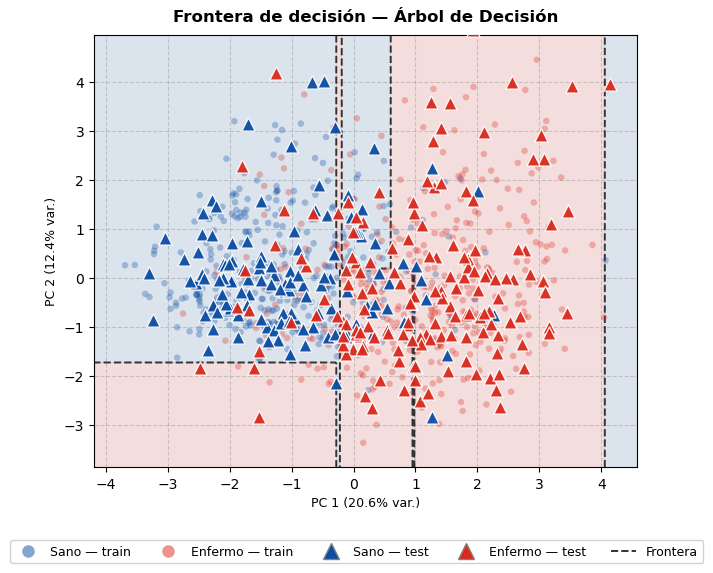

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_07c_frontera_svm.png


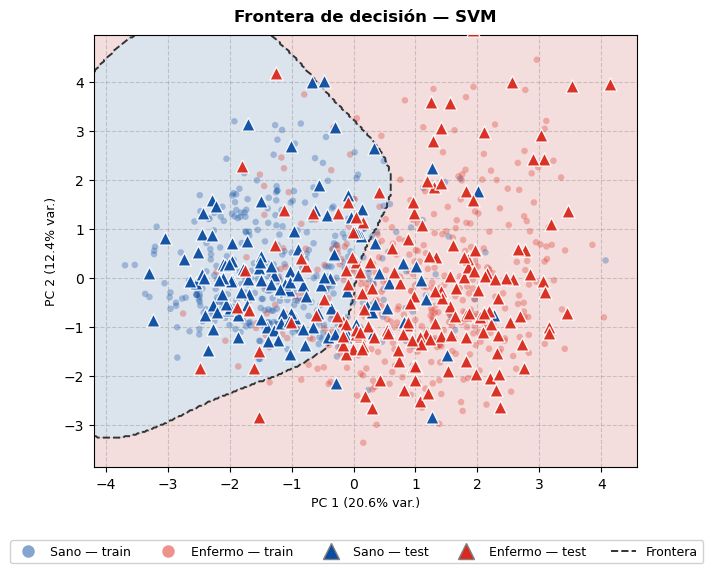

In [ ]:
# PCA 2D para visualización
pesea_2d_bal = PCA(n_components = 2, random_state = 43)
X_train_2d = pesea_2d_bal.fit_transform(X_train_smote)
X_test_2d = pesea_2d_bal.transform(X_test)

y_train_bal_arr = np.asarray(y_train_smote).ravel()
y_test_arr = np.asarray(y_test).ravel()

# Diagnóstico
print(f"{'Variable':<15} {'Shape':<10} Únicos")
print(f"{'X_train_2d':<15} {str(X_train_2d.shape):<10} {np.unique(y_train_bal_arr)}")
print(f"{'y_train_smote':<15} {str(y_train_bal_arr.shape):<10} {np.unique(y_train_bal_arr)}")
print(f"{'X_test_2d':<15} {str(X_test_2d.shape):<10} {np.unique(y_test_arr)}")
print(f"{'y_test':<15} {str(y_test_arr.shape):<10} {np.unique(y_test_arr)}")

# Malla
margen = 0.5
x_min, x_max = X_train_2d[:, 0].min() - margen, X_train_2d[:, 0].max() + margen
y_min, y_max = X_train_2d[:, 1].min() - margen, X_train_2d[:, 1].max() + margen
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

var_pc1 = pesea_2d_bal.explained_variance_ratio_[0] * 100
var_pc2 = pesea_2d_bal.explained_variance_ratio_[1] * 100

leyenda = [
    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = AZUL_TELCEL,
           markersize = 9, markeredgecolor = 'none', alpha = 0.5, label = 'Sano — train'),
    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = ROJO_TECOLOTE,
           markersize = 9, markeredgecolor = 'none', alpha = 0.5, label = 'Enfermo — train'),
    Line2D([0], [0], marker = '^', color = 'w', markerfacecolor = AZUL_TELCEL,
           markersize = 11, markeredgecolor = 'gray', label = 'Sano — test'),
    Line2D([0], [0], marker = '^', color = 'w', markerfacecolor = ROJO_TECOLOTE,
           markersize = 11, markeredgecolor = 'gray', label = 'Enfermo — test'),
    Line2D([0], [0], color = '#333333', linewidth = 1.4, linestyle = '--', label = 'Frontera')
]

nombres_archivo = {
    'KNN': 'h_07a_frontera_knn.png',
    'Árbol de Decisión': 'h_07b_frontera_arbol.png',
    'SVM': 'h_07c_frontera_svm.png',
}

for nombre, gs in resultados.items():

    clf_2d = clone(gs.best_estimator_.named_steps['clf'])
    clf_2d.fit(X_train_2d, y_train_bal_arr)

    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize = (7, 6))
    fig.subplots_adjust(bottom = 0.18, top = 0.90)

    ax.contourf(xx, yy, Z, levels = [-0.5, 0.5, 1.5],
                colors = [AZUL_TELCEL, ROJO_TECOLOTE], alpha  = 0.12,  zorder = 1)
    
    ax.contour(xx, yy, Z, levels = [0.5], colors = ['#333333'],
               linewidths = 1.4, linestyles = '--', zorder = 2)

    for cls, color in [(0, AZUL_TELCEL), (1, ROJO_TECOLOTE)]:
        mask = y_train_bal_arr == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], color = color, 
                   alpha = 0.30, s = 22, marker = 'o', edgecolors = 'none', zorder = 3)

    for cls, color in [(0, AZUL_TELCEL), (1, ROJO_TECOLOTE)]:
        
        mask = y_test_arr == cls
        ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], color = color, alpha = 0.95, 
                   s = 90, marker = '^', edgecolors = 'white', linewidths = 0.9, zorder = 4)

    ax.set_title(f'Frontera de decisión — {nombre}', fontsize = 12, fontweight = 'bold', pad = 10)
    ax.set_xlabel(f'PC 1 ({var_pc1:.1f}% var.)', fontsize = 9)
    ax.set_ylabel(f'PC 2 ({var_pc2:.1f}% var.)', fontsize = 9)
    ax.set_facecolor('#f8f8f8')
    ax.grid(linestyle = '--', alpha = 0.35, color = 'gray')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    fig.legend(handles = leyenda, loc = 'lower center', ncol = 5, bbox_to_anchor = (0.5, 0.01), 
               fontsize = 9, framealpha = 0.9)

    guardar_figura(nombres_archivo[nombre])
    plt.show()

### 6d) Árbol de decisión entrenado con los mejores hiperparámetros

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_08_arbol_decision.png


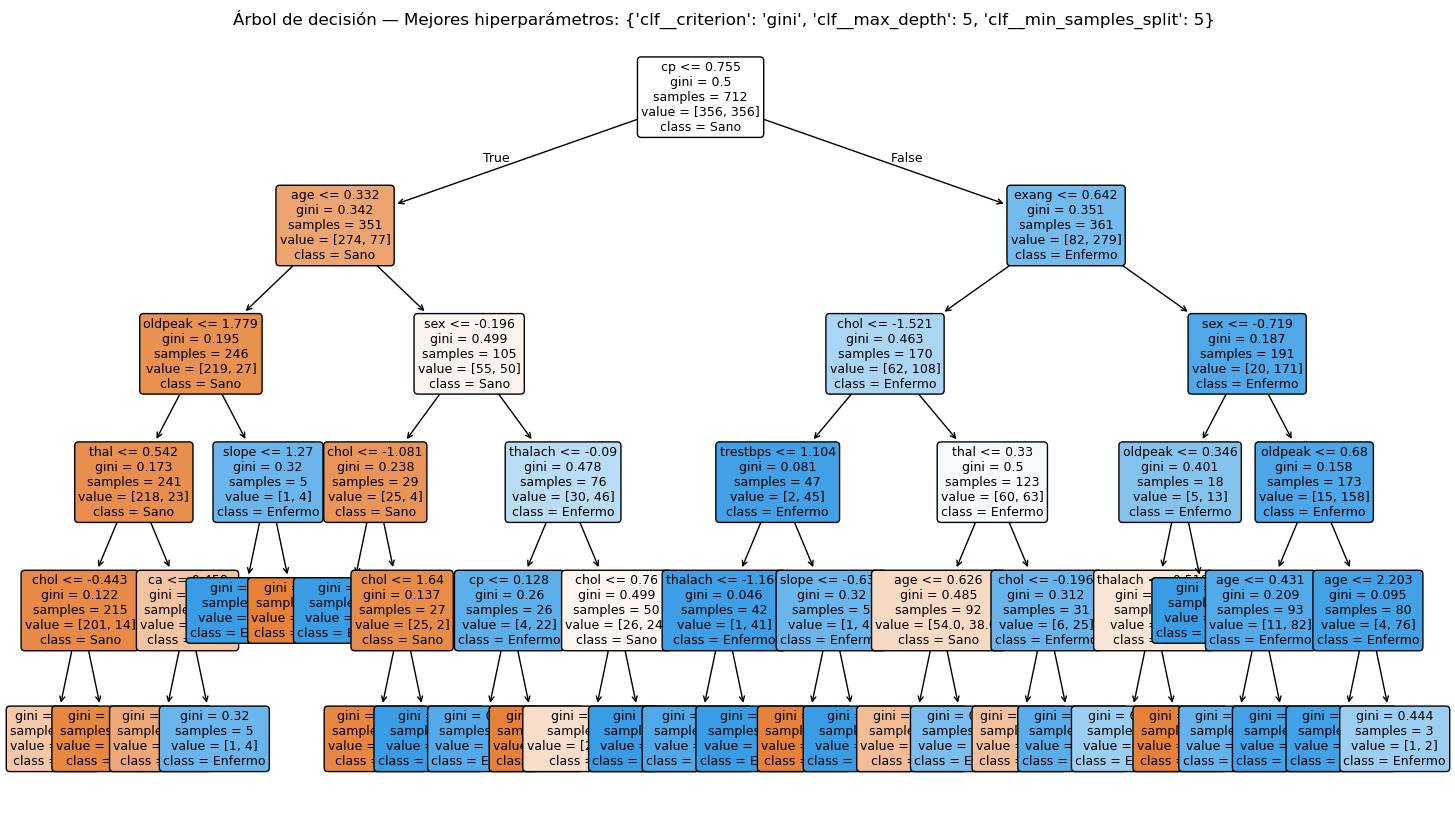

In [39]:
mejor_arbol  = resultados['Árbol de Decisión'].best_estimator_.named_steps['clf']
mejor_params = resultados['Árbol de Decisión'].best_params_

plt.figure(figsize = (18, 10))
plot_tree(mejor_arbol,
          feature_names = columnas_num,
          class_names = ['Sano', 'Enfermo'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title(f'Árbol de decisión — Mejores hiperparámetros: {mejor_params}')
guardar_figura('h_08_arbol_decision.png')
plt.show()

### 6e) Comparación de exactitud entre modelos

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/h_09_comparacion_exactitud.png


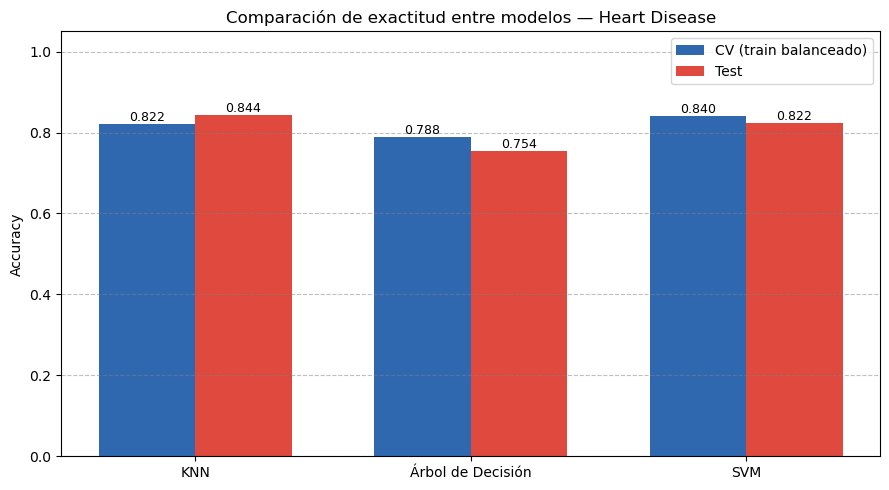

In [40]:
modelos_nom = list(resultados.keys())
acc_cv   = [resultados[m].best_score_ for m in modelos_nom]
acc_test = [accuracy_score(y_test, resultados[m].predict(X_test)) for m in modelos_nom]

fig, ax = plt.subplots(figsize = (9, 5))

x = np.arange(len(modelos_nom))
ancho = 0.35

barras1 = ax.bar(x - ancho/2, acc_cv,   ancho, label = 'CV (train balanceado)', color = AZUL_TELCEL, 
                 alpha = 0.85)
barras2 = ax.bar(x + ancho/2, acc_test, ancho, label = 'Test', color = ROJO_TECOLOTE, alpha = 0.85)

for barras in (barras1, barras2):
    
    for b in barras:
    
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{b.get_height():.3f}', ha = 'center', va = 'bottom', fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels(modelos_nom)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de exactitud entre modelos — Heart Disease')
ax.legend()
ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)
plt.tight_layout()
guardar_figura('h_09_comparacion_exactitud.png')
plt.show()

### 6f) Hiperparámetro más relevante por modelo

Se calcula, para cada hiperparámetro, el rango (máximo menos mínimo) del *accuracy* promedio al fijar ese hiperparámetro en cada uno de sus valores posibles. El hiperparámetro con el mayor rango es el más sensible y, por tanto, el más relevante.

In [41]:
print('Hiperparámetro más relevante por modelo')

for nombre, gs in resultados.items():

    cv_df = pd.DataFrame(gs.cv_results_)
    params_cols = [c for c in cv_df.columns if c.startswith('param_clf__')]

    rangos = {}

    for p in params_cols:

        agg = cv_df.groupby(p, dropna = False)['mean_test_score'].mean()
        rangos[p.replace('param_clf__', '')] = agg.max() - agg.min()

    rangos_df = pd.Series(rangos).sort_values(ascending = False)
    print(f'\n{nombre}')
    print(rangos_df.round(4).to_string())
    print(f'Más relevante: {rangos_df.index[0]} '
          f'(Dif accuracy = {rangos_df.iloc[0]:.4f})')

Hiperparámetro más relevante por modelo

KNN
n_neighbors    0.0249
weights        0.0069
metric         0.0055
Más relevante: n_neighbors (Dif accuracy = 0.0249)

Árbol de Decisión
max_depth            0.0161
min_samples_split    0.0026
criterion            0.0013
Más relevante: max_depth (Dif accuracy = 0.0161)

SVM
C         0.0096
gamma     0.0056
kernel    0.0014
Más relevante: C (Dif accuracy = 0.0096)
